In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
plt.style.use("seaborn-v0_8")

In [10]:
from pathlib import Path
project_root=Path.cwd()

if project_root.name == "notebook":
    project_root = project_root.parent

data_path = project_root / "data"/ "fraudTest.csv"

raw = pd.read_csv(data_path)

if "Unnamed: 0" in raw.columns:
    raw = raw.drop(columns=["Unnamed: 0"])
raw.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [11]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  555719 non-null  object 
 1   cc_num                 555719 non-null  int64  
 2   merchant               555719 non-null  object 
 3   category               555719 non-null  object 
 4   amt                    555719 non-null  float64
 5   first                  555719 non-null  object 
 6   last                   555719 non-null  object 
 7   gender                 555719 non-null  object 
 8   street                 555719 non-null  object 
 9   city                   555719 non-null  object 
 10  state                  555719 non-null  object 
 11  zip                    555719 non-null  int64  
 12  lat                    555719 non-null  float64
 13  long                   555719 non-null  float64
 14  city_pop               555719 non-nu

In [ ]:
# raw.isnull().sum()
dup_count = raw.duplicated().sum()


np.int64(0)

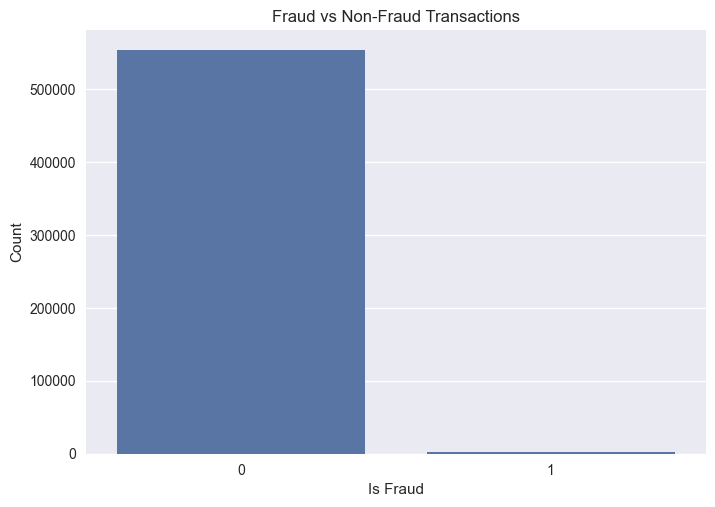

In [20]:
# class balance
fraud_counts = raw["is_fraud"].value_counts()
fraud_rate = raw["is_fraud"].mean()

sns.countplot(data=raw, x="is_fraud")
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Is Fraud")
plt.ylabel("Count")
plt.show()


# imbalance data ??
# KPI ?? you cant use accuracy --> precision, recall, F1-score or confusion matrix

In [ ]:
# Convert time column
raw['trans_date_trans_time'] = pd.to_datetime(raw['trans_date_trans_time'])
raw['dob'] = pd.to_datetime(raw['dob'])



In [31]:
raw['trans_hour'] = raw['trans_date_trans_time'].dt.hour
raw['trans_dayofweek'] = raw['trans_date_trans_time'].dt.dayofweek
raw['trans_minute'] = raw['trans_date_trans_time'].dt.minute
raw['trans_month'] = raw['trans_date_trans_time'].dt.month

# raw[['trans_date_trans_time', 'trans_hour', 'trans_minute', 'trans_dayofweek', 'trans_month','is_fraud']].tail(20)

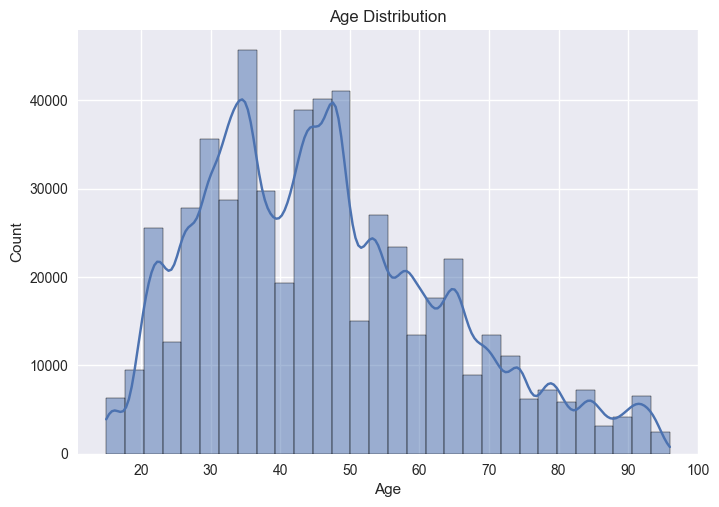

In [36]:
raw['age'] = ((raw['trans_date_trans_time'] - raw['dob']).dt.days // 365.25)

raw.age.describe()

# you can plot
sns.histplot(data=raw, x="age", bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [ ]:
# assumption about age against fraud ??
# Older individuals might be more likely to commit fraud
# Younger individuals might be more likely to be victims of fraud ?? 

# younger age (15-25)
raw_young = raw[raw['age'] <= 25]
# you can plot
raw_young_fraud_counts = raw_young["is_fraud"].value_counts(normalize=True)
raw_young_fraud_counts


is_fraud
0    0.995928
1    0.004072
Name: proportion, dtype: float64

In [48]:
# between 25 to 70
raw_middle_aged = raw[(raw['age'] > 25) & (raw['age'] <= 70)]
# you can plot
raw_middle_aged_fraud_counts = raw_middle_aged["is_fraud"].value_counts(normalize=True)
raw_middle_aged_fraud_counts


is_fraud
0    0.996275
1    0.003725
Name: proportion, dtype: float64

In [50]:
min(6,5)

5

In [51]:
sample_size = min(200000,len(raw))
raw_sample = raw.sample(n=sample_size, random_state=42)
raw_sample.shape

(200000, 27)

In [56]:
raw_sample.columns  

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud', 'trans_hour', 'trans_dayofweek',
       'trans_month', 'trans_minute', 'age'],
      dtype='object')

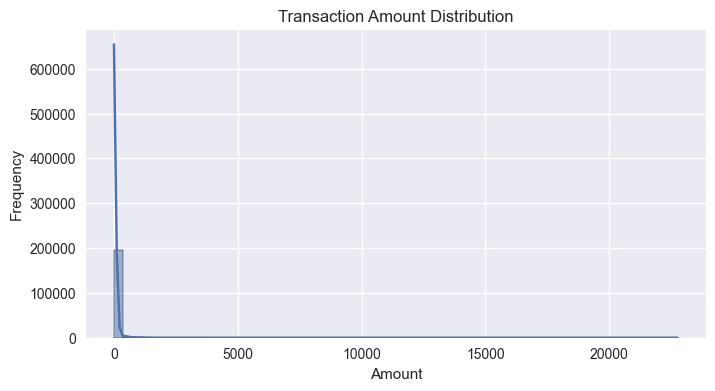

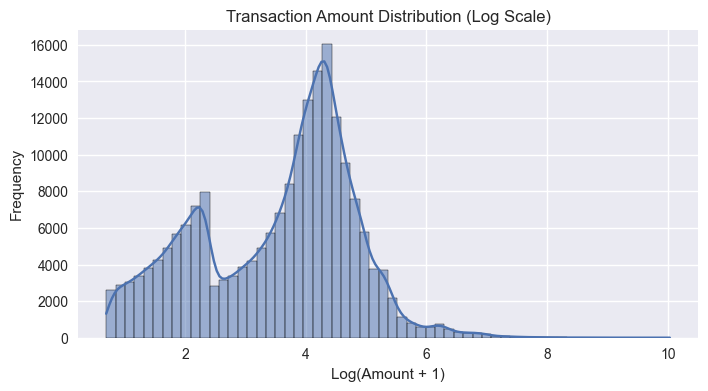

In [54]:
raw_sample.columns

# data dictionary
# age : Age of the individual
# is_fraud : Whether the transaction is fraudulent
# trans_date_trans_time : Timestamp of the transaction
# cc_num : Credit card number
# amt : Transaction amount

plt.figure(figsize=(8, 4))
sns.histplot(raw_sample["amt"], bins=60, kde=True)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(np.log1p(raw_sample["amt"]), bins=60, kde=True)
plt.title("Transaction Amount Distribution (Log Scale)")
plt.xlabel("Log(Amount + 1)")
plt.ylabel("Frequency")
plt.show()

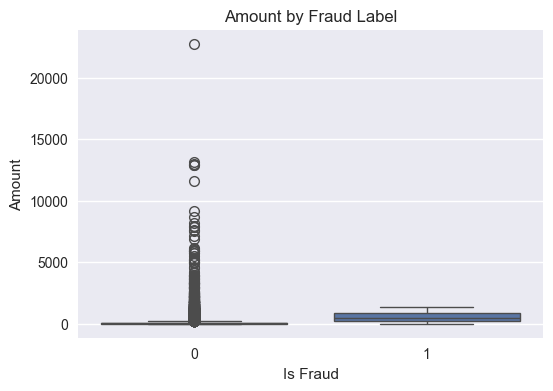

In [55]:
plt.figure(figsize=(6, 4))
sns.boxplot(x="is_fraud", y="amt", data=raw_sample)
plt.title("Amount by Fraud Label")
plt.xlabel("Is Fraud")
plt.ylabel("Amount")
plt.show()

In [ ]:
# create data dictionary( In excel file)
# 4 column should be there - 1) column_name, 2) defination, 3) assumtion 4) observation
# Do experiment with others columns ( see the distributions, effect on target columns etc. )